<a href="https://colab.research.google.com/github/LuciaBossio/Data-Science-III-Entrega-final-Garc-a-Bossio/blob/main/Data_Science_III_Entrega_final_Garc%C3%ADa_Bossio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install spacy nltk scikit-learn torch
!python -m spacy download en_core_web_sm

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
import kagglehub
import pandas as pd
import os
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)
df = pd.read_csv(full_path)
print(f"Forma del dataset: {df.shape}")
print(df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Forma del dataset: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


/tmp/ipykernel_4292/889166509.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='coolwarm')


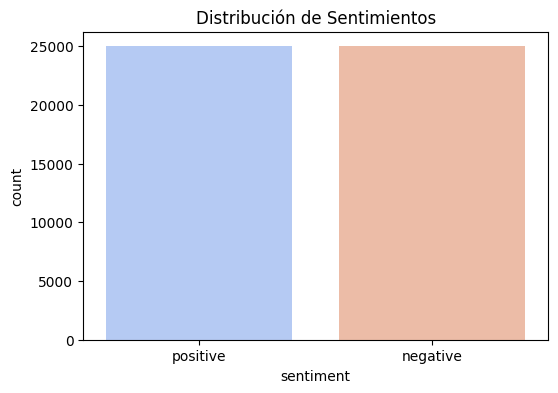

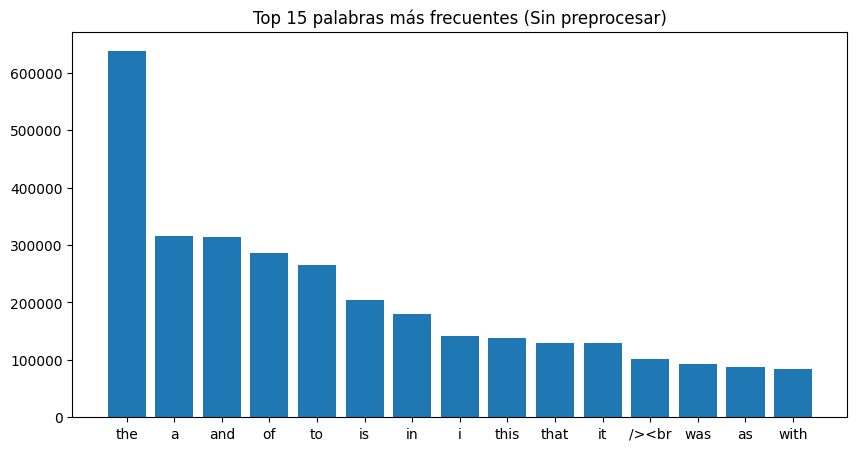

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', palette='coolwarm')
plt.title('Distribución de Sentimientos')
plt.show()

all_words = ' '.join(df['review'].str.lower()).split()
most_common = Counter(all_words).most_common(15)

words, counts = zip(*most_common)
plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title('Top 15 palabras más frecuentes (Sin preprocesar)')
plt.show()

In [7]:
import re
import nltk
import spacy
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
lemmatizer_nltk = WordNetLemmatizer()

def clean_text_regex(text):

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = text.lower().strip()
    return text

def compare_lemmatization(text):

    tokens = word_tokenize(text)


    nltk_lemmas = [lemmatizer_nltk.lemmatize(w) for w in tokens]


    doc = nlp(" ".join(tokens))
    spacy_lemmas = [token.lemma_ for token in doc]

    return tokens, nltk_lemmas, spacy_lemmas


sample_text = df['review'].iloc[0]
cleaned_sample = clean_text_regex(sample_text)
tokens, nltk_res, spacy_res = compare_lemmatization(cleaned_sample)

print(f"Texto Original (primeros 50 caracteres): {sample_text[:50]}...")
print(f"Tokens: {tokens[:5]}")
print(f"NLTK Lemmas: {nltk_res[:5]}")
print(f"spaCy Lemmas: {spacy_res[:5]}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Texto Original (primeros 50 caracteres): One of the other reviewers has mentioned that afte...
Tokens: ['one', 'of', 'the', 'other', 'reviewers']
NLTK Lemmas: ['one', 'of', 'the', 'other', 'reviewer']
spaCy Lemmas: ['one', 'of', 'the', 'other', 'reviewer']


In [8]:
def preprocess_final(text):
    text = clean_text_regex(text)
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

df_subset = df.sample(5000, random_state=42).copy()
print("Procesando textos... esto puede tardar un minuto.")
df_subset['clean_review'] = df_subset['review'].apply(preprocess_final)
print("¡Limpieza terminada!")

Procesando textos... esto puede tardar un minuto.
¡Limpieza terminada!


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df_subset['clean_review']
y = df_subset['sentiment'].map({'positive': 1, 'negative': 0}).values


X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

print(f"Dimensiones de X_train_tfidf: {X_train_tfidf.shape}")

Dimensiones de X_train_tfidf: (4000, 5000)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class TextClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifier, self).__init__()

        self.layer1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(p=0.5)

        self.layer2 = nn.Linear(512, 128)
        self.out = nn.Linear(128, 2)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.out(x)
        return x


input_dim = X_train_tfidf.shape[1]
model = TextClassifier(input_dim)

print(model)

TextClassifier(
  (layer1): Linear(in_features=5000, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (layer2): Linear(in_features=512, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)


In [11]:
import numpy as np


X_train_t = torch.FloatTensor(X_train_tfidf)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test_tfidf)
y_test_t = torch.LongTensor(y_test)


train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


patience = 5
min_val_loss = np.inf
counter = 0
epochs = 50

print("Iniciando entrenamiento...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()


    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_t)
        val_loss = criterion(val_outputs, y_test_t).item()

    avg_train_loss = train_loss / len(train_loader)
    print(f'Época {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}')


    if val_loss < min_val_loss:
        min_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), 'best_model.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"--- Early Stopping activado en la época {epoch+1} ---")
            break

Iniciando entrenamiento...
Época 1: Train Loss: 0.4401 | Val Loss: 0.3731
Época 2: Train Loss: 0.1424 | Val Loss: 0.4996
Época 3: Train Loss: 0.0564 | Val Loss: 0.6975
Época 4: Train Loss: 0.0612 | Val Loss: 0.6986
Época 5: Train Loss: 0.0595 | Val Loss: 0.7401
Época 6: Train Loss: 0.0461 | Val Loss: 0.8263
--- Early Stopping activado en la época 6 ---


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    Negative       0.86      0.79      0.82       506
    Positive       0.80      0.87      0.83       494

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



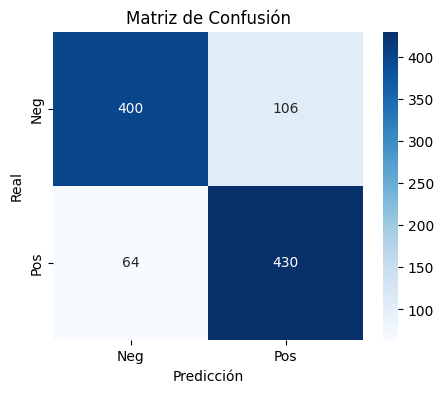

In [12]:
from sklearn.metrics import classification_report, confusion_matrix


model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)


print("--- Reporte de Clasificación ---")
print(classification_report(y_test, predicted, target_names=['Negative', 'Positive']))


cm = confusion_matrix(y_test, predicted)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()